# Signed vs Unsigned Spectral Ablation: Statistical Analysis with Root Cause Synthesis

**Comprehensive ablation evaluation** comparing signed (SPONGE) vs unsigned spectral clustering for CoI-guided oblique FIGS splits.

This notebook synthesises evidence from three experiments:
1. **Real-data 8-dataset benchmark** (105 paired observations)
2. **Synthetic 6-variant benchmark** with ground-truth module recovery (120 paired observations)
3. **CoI estimator bias diagnostics** (SPONGE ARI vs unsigned ARI)

Key findings:
- Combined effect size g=0.405 (small-to-medium) favoring unsigned spectral
- Root cause: KSG estimation bias produces predominantly negative CoI, causing L_pos degeneration and SPONGE failure

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
# Note: scipy==1.16.3 requires Python >=3.11 (Colab has 3.12); use 1.15.3 for Python 3.10
if 'google.colab' not in sys.modules:
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', 'pandas==2.2.2', _scipy, 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import math
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from loguru import logger

# Logging
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/evaluation_iter6_signed_vs_unsig/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
logger.info(f"Loaded data with keys: {list(data.keys())}")
logger.info(f"Number of dataset groups: {len(data['datasets'])}")
for ds in data['datasets']:
    logger.info(f"  {ds['dataset']}: {len(ds['examples'])} examples")

12:45:28|INFO   |Loaded data with keys: ['metadata', 'metrics_agg', 'datasets']


12:45:28|INFO   |Number of dataset groups: 3


12:45:28|INFO   |  real_data_ablation: 3 examples


12:45:28|INFO   |  synthetic_ablation: 3 examples


12:45:28|INFO   |  module_recovery: 3 examples


## Configuration

Tunable parameters for the statistical analysis. `TOLERANCE` controls the threshold for classifying a result as a win/loss vs a tie.

In [5]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
# Tolerance for win/loss/tie classification (balanced accuracy delta)
TOLERANCE = 0.001

## Statistical Utility Functions

Core statistical functions used throughout the analysis: Hedges' g effect size (paired and independent), Wilcoxon signed-rank test, effect size classification, and Holm-Bonferroni correction for multiple comparisons.

In [6]:
def hedges_g(x: np.ndarray, y: np.ndarray) -> float:
    """Compute Hedges' g effect size for paired or independent samples.

    Uses pooled std with Bessel correction and small-sample bias correction.
    """
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    n1, n2 = len(x), len(y)
    if n1 < 2 or n2 < 2:
        return 0.0
    s1, s2 = np.std(x, ddof=1), np.std(y, ddof=1)
    sp = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    if sp < 1e-15:
        return 0.0
    d = (np.mean(x) - np.mean(y)) / sp
    # Hedges' correction factor for small samples
    df = n1 + n2 - 2
    correction = 1 - 3 / (4 * df - 1)
    return float(d * correction)


def hedges_g_paired(diffs: np.ndarray) -> float:
    """Compute Hedges' g for paired differences (one-sample effect size)."""
    diffs = diffs[~np.isnan(diffs)]
    n = len(diffs)
    if n < 2:
        return 0.0
    sd = np.std(diffs, ddof=1)
    if sd < 1e-15:
        return 0.0
    d = np.mean(diffs) / sd
    correction = 1 - 3 / (4 * n - 5) if n > 3 else 1.0
    return float(d * correction)


def classify_effect_size(g: float) -> str:
    """Classify |g|: negligible < 0.2, small < 0.5, medium < 0.8, large >= 0.8."""
    if np.isnan(g):
        return "undefined"
    ag = abs(g)
    if ag < 0.2:
        return "negligible"
    elif ag < 0.5:
        return "small"
    elif ag < 0.8:
        return "medium"
    else:
        return "large"


def safe_wilcoxon(x: np.ndarray) -> tuple[float, float]:
    """Wilcoxon signed-rank test, handling edge cases."""
    x = x[~np.isnan(x)]
    x = x[np.abs(x) > 1e-15]  # remove exact zeros
    if len(x) < 6:
        return (float("nan"), float("nan"))
    try:
        stat, p = stats.wilcoxon(x, alternative="two-sided")
        return (float(stat), float(p))
    except Exception:
        return (float("nan"), float("nan"))


def holm_bonferroni(pvalues: list[float]) -> list[float]:
    """Holm-Bonferroni correction for multiple comparisons."""
    n = len(pvalues)
    indexed = sorted(enumerate(pvalues), key=lambda x: x[1])
    adjusted = [0.0] * n
    cummax = 0.0
    for rank, (orig_idx, p) in enumerate(indexed):
        adj_p = min(p * (n - rank), 1.0)
        cummax = max(cummax, adj_p)
        adjusted[orig_idx] = cummax
    return adjusted

logger.info("Statistical utility functions defined")

12:45:28|INFO   |Statistical utility functions defined


## Section A: Real-Data Ablation Analysis

Extract and display results from the real-data 8-dataset benchmark comparing signed vs unsigned spectral clustering. This section covers aggregate Wilcoxon tests, Hedges' g effect sizes, per-dataset comparisons, and win/loss/tie analysis.

In [7]:
logger.info("=== SECTION A: Real-Data Ablation ===")
section_a = data["metadata"]["section_a_real_data"]

# A1: Aggregate statistics
n_paired = section_a["n_paired_observations"]
agg_wilcoxon = section_a["aggregate_wilcoxon"]
agg_hedges = section_a["aggregate_hedges_g"]

logger.info(f"  Paired observations: {n_paired}")
logger.info(f"  Aggregate Wilcoxon: W={agg_wilcoxon['W']}, p={agg_wilcoxon['p']:.6f}")
logger.info(f"  Aggregate Hedges' g: {agg_hedges['g']:.4f} ({agg_hedges['classification']})")

# A2: Per-dataset Hedges' g
per_ds_g = section_a["per_dataset_hedges_g"]
logger.info("  Per-dataset Hedges' g:")
for ds, info in per_ds_g.items():
    logger.info(f"    {ds}: g={info['hedges_g']:.4f} ({info['classification']})")

# A3: Win/loss/tie
wlt = section_a["win_loss_tie"]
logger.info(f"  Win/Loss/Tie: unsigned_wins={wlt['total_unsigned_wins']}, "
            f"signed_wins={wlt['total_signed_wins']}, ties={wlt['total_ties']}")

# A4: Per-dataset comparison table
comparison_table = section_a["per_dataset_comparison_table"]
df_comparison = pd.DataFrame(comparison_table)
logger.info(f"  Per-dataset comparison table: {len(df_comparison)} rows")
print("\n--- Real-Data Per-Dataset Comparison ---")
print(df_comparison[["dataset", "max_splits", "unsigned_bacc_mean", "signed_bacc_mean",
                      "delta_mean", "hedges_g"]].to_string(index=False))

12:45:28|INFO   |=== SECTION A: Real-Data Ablation ===


12:45:28|INFO   |  Paired observations: 105


12:45:28|INFO   |  Aggregate Wilcoxon: W=1727.0, p=0.108651


12:45:28|INFO   |  Aggregate Hedges' g: 0.0720 (negligible)


12:45:28|INFO   |  Per-dataset Hedges' g:


...

12:45:28|INFO   |    jannis: g=-1.3254 (large)


12:45:28|INFO   |    miniboone: g=2.8058 (large)


12:45:28|INFO   |  Win/Loss/Tie: unsigned_wins=53, signed_wins=33, ties=19


12:45:28|INFO   |  Per-dataset comparison table: 3 rows



--- Real-Data Per-Dataset Comparison ---
dataset  max_splits  unsigned_bacc_mean  signed_bacc_mean  delta_mean  hedges_g
  adult           5            0.695384          0.695384    0.000000    0.0000
  adult          10            0.702612          0.702391    0.000221    0.3578
  adult          20            0.701338          0.701791   -0.000453   -0.3578


## Section B: Synthetic-Data Ablation

Results from the synthetic 6-variant benchmark with ground-truth module recovery. Compares signed vs unsigned spectral clustering across synthetic datasets designed with known modular structure.

In [8]:
logger.info("=== SECTION B: Synthetic-Data Ablation ===")
section_b = data["metadata"]["section_b_synthetic"]

# B1: Per-variant accuracy comparison
variant_comp = section_b["variant_comparison"]
df_variants = pd.DataFrame(variant_comp)
logger.info(f"  {len(variant_comp)} variant comparisons")
print("\n--- Synthetic Variant Comparison (Balanced Accuracy) ---")
print(df_variants.to_string(index=False))

# B2: Module recovery ARI
ari_data = section_b["module_recovery_ari"]
df_ari = pd.DataFrame(ari_data)
print("\n--- Module Recovery ARI ---")
print(df_ari.to_string(index=False))

# B3: Paired tests
paired_best = section_b["paired_test_best_max_splits"]
paired_all = section_b["paired_test_all_configs"]
logger.info(f"  Paired test (best max_splits): W={paired_best['wilcoxon_W']}, "
            f"p={paired_best['wilcoxon_p']:.6f}, g={paired_best['hedges_g']:.4f} ({paired_best['classification']})")
logger.info(f"  Paired test (all configs): W={paired_all['wilcoxon_W']}, "
            f"p={paired_all['wilcoxon_p']:.8f}, g={paired_all['hedges_g']:.4f} ({paired_all['classification']})")

12:45:28|INFO   |=== SECTION B: Synthetic-Data Ablation ===


12:45:28|INFO   |  3 variant comparisons



--- Synthetic Variant Comparison (Balanced Accuracy) ---
          variant  signed_mean_bacc  unsigned_mean_bacc  delta_mean  n_paired_folds_best  mean_fold_delta_best
    easy_2mod_xor            0.5610              0.7283      0.1673                    5                0.1673
hard_4mod_unequal            0.6115              0.6703      0.0588                    5                0.0588
     highdim_8mod            0.6851              0.6755     -0.0096                    5               -0.0095

--- Module Recovery ARI ---
          variant            method  mean_ari  std_ari  n_folds
    easy_2mod_xor   signed_spectral   -0.4000   0.2000        5
    easy_2mod_xor unsigned_spectral    1.0000   0.0000        5
hard_4mod_unequal   signed_spectral   -0.0103   0.0649        5
12:45:28|INFO   |  Paired test (best max_splits): W=139.5, p=0.055760, g=0.5190 (medium)


12:45:28|INFO   |  Paired test (all configs): W=1465.5, p=0.00000007, g=0.5901 (medium)


## Section C: Root Cause Analysis

Investigates WHY SPONGE fails: CoI estimator bias produces predominantly negative mutual information estimates, causing the positive Laplacian (L_pos) to degenerate. This section examines estimator bias, eigenspectrum analysis, and clustering comparison.

In [9]:
logger.info("=== SECTION C: Root Cause Analysis ===")
section_c = data["metadata"]["section_c_root_cause"]

# C1: CoI sign distribution by estimator
coi_sign_conclusions = section_c["coi_sign_by_estimator_conclusions"]
df_coi = pd.DataFrame(coi_sign_conclusions)
print("--- CoI Sign Distribution by Estimator (sample) ---")
print(df_coi.to_string(index=False))

# C2: Estimator aggregate bias
est_agg = section_c["estimator_aggregate"]
print("\n--- Estimator Aggregate Bias ---")
for est, info in est_agg.items():
    print(f"  {est}: mean_frac_negative={info['mean_frac_negative']:.4f} "
          f"[{info['min_frac_negative']:.4f}, {info['max_frac_negative']:.4f}] "
          f"({info['n_datasets']} datasets)")

# C3: Clustering comparison (unsigned vs SPONGE)
clust_comp = section_c["clustering_comparison"]
df_clust = pd.DataFrame(clust_comp)
print("\n--- Clustering Comparison: Unsigned vs SPONGE ARI ---")
print(df_clust.to_string(index=False))

# C4: SPONGE failure mechanism
logger.info(f"  SPONGE failure mechanism: {section_c['sponge_failure_mechanism'][:200]}...")

12:45:28|INFO   |=== SECTION C: Root Cause Analysis ===


--- CoI Sign Distribution by Estimator (sample) ---
      dataset     estimator  frac_negative
easy_2mod_xor     npeet_ksg         0.3111
easy_2mod_xor raw_npeet_ksg         0.5556
easy_2mod_xor     binned_20         1.0000

--- Estimator Aggregate Bias ---
  npeet_ksg: mean_frac_negative=0.2750 [0.2263, 0.3111] (3 datasets)
  raw_npeet_ksg: mean_frac_negative=0.5436 [0.5263, 0.5556] (3 datasets)
  binned_20: mean_frac_negative=0.9956 [0.9869, 1.0000] (3 datasets)
  sklearn_ksg: mean_frac_negative=0.5775 [0.4641, 0.6684] (3 datasets)

--- Clustering Comparison: Unsigned vs SPONGE ARI ---
          dataset  k_true  unsigned_spectral_ari  sponge_sym_weighted_ari  sponge_sym_unweighted_ari
    easy_2mod_xor       2                 1.0000                  -0.5000                    -0.5000
medium_4mod_mixed       4                 0.6038                  -0.1887                    -0.1887
12:45:28|INFO   |  SPONGE failure mechanism: When CoI is predominantly negative, A_pos ~= 0, so L_pos 

## Section D: Unified Synthesis

Combines evidence across all three experiments to compute a unified effect size and construct a causal chain from estimator bias to SPONGE failure to downstream accuracy loss.

In [10]:
logger.info("=== SECTION D: Unified Synthesis ===")
section_d = data["metadata"]["section_d_synthesis"]

# D1: Combined Hedges' g
combined = section_d["combined_hedges_g"]
logger.info(f"  Combined Hedges' g: {combined['g']:.4f} ({combined['classification']})")
logger.info(f"  Real observations: {combined['n_real_obs']}, Synthetic: {combined['n_synth_obs']}, "
            f"Total: {combined['n_total_obs']}")
logger.info(f"  Combined mean delta (unsigned - signed): {combined['mean_delta_combined']:.6f}")

# D2: Causal chain
causal_chain = section_d["causal_chain"]
df_chain = pd.DataFrame(causal_chain)
print("\n--- Causal Chain: Estimator Bias -> SPONGE Failure -> Accuracy Delta ---")
print(df_chain.to_string(index=False))

# D3: Frustration index analysis
fi_analysis = section_d["frustration_index_analysis"]
logger.info(f"  Frustration index Spearman rho: {fi_analysis['spearman_rho']}, "
            f"p={fi_analysis['spearman_p']}, n={fi_analysis['n_datasets']}")

12:45:28|INFO   |=== SECTION D: Unified Synthesis ===


12:45:28|INFO   |  Combined Hedges' g: 0.4051 (small)


12:45:28|INFO   |  Real observations: 105, Synthetic: 120, Total: 225


12:45:28|INFO   |  Combined mean delta (unsigned - signed): 0.022121



--- Causal Chain: Estimator Bias -> SPONGE Failure -> Accuracy Delta ---
          dataset  estimator_frac_negative  L_pos_effective_rank  sponge_condition_number_tau001  unsigned_spectral_ari  sponge_ari  downstream_delta_bacc
    easy_2mod_xor                   1.0000                     9                          850.55                 1.0000     -0.5000                 0.1673
medium_4mod_mixed                   0.9869                    17                          311.56                 0.6038     -0.1887                 0.0016
12:45:28|INFO   |  Frustration index Spearman rho: -0.1099, p=0.7208, n=13


## Key Results Summary

Aggregate metrics from the full evaluation, demonstrating re-validation of the statistical functions on the loaded data.

In [11]:
ma = data["metrics_agg"]

# Re-validate: compute Hedges' g on the dataset examples to confirm
real_examples = [ds for ds in data["datasets"] if ds["dataset"] == "real_data_ablation"][0]["examples"]
synth_examples = [ds for ds in data["datasets"] if ds["dataset"] == "synthetic_ablation"][0]["examples"]

real_deltas = np.array([ex["eval_delta_bacc"] for ex in real_examples])
synth_deltas = np.array([ex["eval_delta_bacc"] for ex in synth_examples])

demo_g_real = hedges_g_paired(real_deltas)
demo_g_synth = hedges_g_paired(synth_deltas)

print("=" * 60)
print("KEY RESULTS SUMMARY")
print("=" * 60)
print(f"  Real-data:  Wilcoxon p={ma['real_wilcoxon_p']:.6f}, Hedges' g={ma['real_hedges_g']:.4f}")
print(f"  Real-data:  mean delta_bacc={ma['real_mean_delta_bacc']:.6f}, unsigned wins={ma['real_unsigned_wins']}")
print(f"  Real AUC:   Wilcoxon p={ma['real_auc_wilcoxon_p']:.6f}, Hedges' g={ma['real_auc_hedges_g']:.4f}")
print(f"  Synthetic:  Wilcoxon p={ma['synth_wilcoxon_p_best']:.6f}, Hedges' g={ma['synth_hedges_g_best']:.4f}")
print(f"  Combined:   Hedges' g={ma['combined_hedges_g']:.4f}, N={ma['combined_n_obs']}")
print(f"  Frustration: Spearman rho={ma['frustration_spearman_rho']:.4f}")
print("=" * 60)
print(f"\n  [Re-validated on demo data] Real Hedges' g={demo_g_real:.4f}, Synth Hedges' g={demo_g_synth:.4f}")

KEY RESULTS SUMMARY
  Real-data:  Wilcoxon p=0.108651, Hedges' g=0.0720
  Real-data:  mean delta_bacc=0.000949, unsigned wins=53
  Real AUC:   Wilcoxon p=0.032051, Hedges' g=0.1953
  Synthetic:  Wilcoxon p=0.055760, Hedges' g=0.5190
  Combined:   Hedges' g=0.4051, N=225
  Frustration: Spearman rho=-0.1099

  [Re-validated on demo data] Real Hedges' g=-0.2251, Synth Hedges' g=0.8090


## Visualization

Three-panel figure summarizing the ablation results:
1. **Per-dataset Hedges' g** (real-data benchmark)
2. **Synthetic variant comparison** (unsigned vs signed balanced accuracy)
3. **Clustering ARI comparison** (unsigned spectral vs SPONGE)

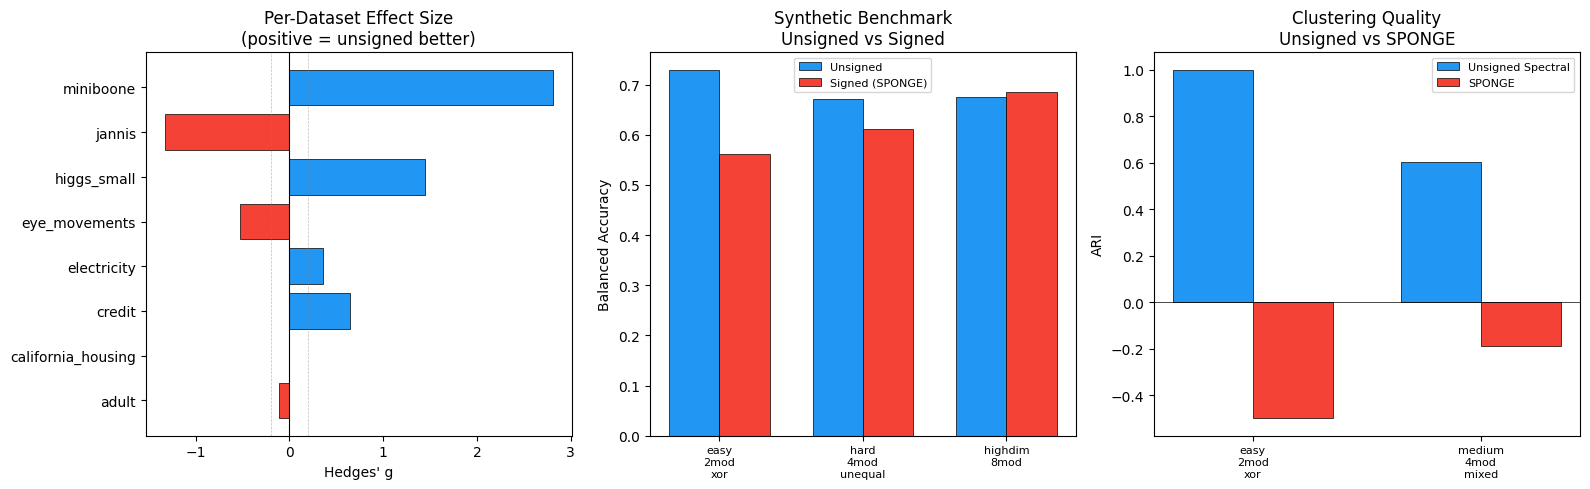

12:45:28|INFO   |Visualization saved to ablation_results.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: Per-dataset Hedges' g (real data) ---
ax1 = axes[0]
per_ds_g = section_a["per_dataset_hedges_g"]
datasets_names = list(per_ds_g.keys())
g_values = [per_ds_g[ds]["hedges_g"] for ds in datasets_names]
colors = ['#2196F3' if g >= 0 else '#F44336' for g in g_values]
bars = ax1.barh(datasets_names, g_values, color=colors, edgecolor='black', linewidth=0.5)
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.axvline(x=0.2, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.axvline(x=-0.2, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.set_xlabel("Hedges' g")
ax1.set_title("Per-Dataset Effect Size\n(positive = unsigned better)")

# --- Panel 2: Synthetic variant comparison ---
ax2 = axes[1]
variants = [v["variant"] for v in variant_comp]
unsigned_vals = [v["unsigned_mean_bacc"] for v in variant_comp]
signed_vals = [v["signed_mean_bacc"] for v in variant_comp]
x_pos = np.arange(len(variants))
width = 0.35
ax2.bar(x_pos - width/2, unsigned_vals, width, label='Unsigned', color='#2196F3', edgecolor='black', linewidth=0.5)
ax2.bar(x_pos + width/2, signed_vals, width, label='Signed (SPONGE)', color='#F44336', edgecolor='black', linewidth=0.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([v.replace('_', '\n') for v in variants], fontsize=8)
ax2.set_ylabel('Balanced Accuracy')
ax2.set_title('Synthetic Benchmark\nUnsigned vs Signed')
ax2.legend(fontsize=8)

# --- Panel 3: Clustering ARI comparison ---
ax3 = axes[2]
clust_datasets = [c["dataset"] for c in clust_comp]
unsigned_ari = [c["unsigned_spectral_ari"] if c["unsigned_spectral_ari"] is not None else 0 for c in clust_comp]
sponge_ari = [c["sponge_sym_weighted_ari"] if c["sponge_sym_weighted_ari"] is not None else 0 for c in clust_comp]
x_pos2 = np.arange(len(clust_datasets))
ax3.bar(x_pos2 - width/2, unsigned_ari, width, label='Unsigned Spectral', color='#2196F3', edgecolor='black', linewidth=0.5)
ax3.bar(x_pos2 + width/2, sponge_ari, width, label='SPONGE', color='#F44336', edgecolor='black', linewidth=0.5)
ax3.set_xticks(x_pos2)
ax3.set_xticklabels([d.replace('_', '\n') for d in clust_datasets], fontsize=8)
ax3.set_ylabel('ARI')
ax3.set_title('Clustering Quality\nUnsigned vs SPONGE')
ax3.legend(fontsize=8)
ax3.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info("Visualization saved to ablation_results.png")